# Project - AI for Medical Diagnosis and Prediction | Week #4

In this notebook, we continue our analysis of the MIMIC-CXR dataset by training convolutional neural networks for pathology classification. The objective is to perform a benchmark analysis of several models to detect the presence of pathologies in chest x-rays.

In addition, we will train a segmentation model with a classification head. The objective is to see if the segmentation of relevant areas helps for pathology detection.

We will use a subset of the **MIMIC-CXR dataset** **[1][2]**. The MIMIC Chest X-ray (MIMIC-CXR) Database v2.0.0 is a large, publicly available dataset of chest radiographs in DICOM format, accompanied by free-text radiology reports. It contains 377,110 images from 227,835 radiographic studies conducted at the Beth Israel Deaconess Medical Center in Boston, MA. The dataset has been de-identified in compliance with the US Health Insurance Portability and Accountability Act of 1996 (HIPAA) Safe Harbor requirements. All protected health information (PHI) has been removed. More details: [https://mimic.mit.edu/docs/iv/modules/cxr/](https://mimic.mit.edu/docs/iv/modules/cxr/)

<div class="alert alert-block alert-info">
<b>Your tasks are the following:</b>  <br>
- Load the dataset using the same train, validation and test splits as during the previous week <i>(Task 1)</i> <br>
- Implement one (or two) convolutional neural networks (pretrained) and fine-tune them on your dataset <i>(Task 2)</i> <br>
- Evaluate the performance of the models using appropriate metrics <i>(Task 3)</i> <br>
- Implement a segmentation network of your choice (pretrained) <i>(Task 4)</i> <br>
- Add a classification head in addition to the segmentation network and train it on your dataset <i>(Task 4*)</i> <br>
- Evaluate the performance of the model, save the results of both models in a csv file using various appropriate metrics <i>(Task 4)</i> <br>
- Save the models and comment on their performance on the validation set <i>(Task 5)</i> <br>
- Compute the performance of the best model on the test set <i>(Task 5*)</i> <br>
</div>

**[1]** Johnson, A., Pollard, T., Mark, R., Berkowitz, S., & Horng, S. (2024). MIMIC-CXR Database (version 2.1.0). PhysioNet. [https://doi.org/10.13026/4jqj-jw95](https://doi.org/10.13026/4jqj-jw95).

**[2]** Johnson, A.E.W., Pollard, T.J., Berkowitz, S.J. et al. MIMIC-CXR, a de-identified publicly available database of chest radiographs with free-text reports. Sci Data 6, 317 (2019). [https://doi.org/10.1038/s41597-019-0322-0](https://doi.org/10.1038/s41597-019-0322-0)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

!pip install pydicom
#!python3.8 -m pip install opencv-python
import pydicom
import time
import cv2
from PIL import Image
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import tv_tensors
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
import random

seed = 42
random.seed(seed)
np.random.seed(seed)

In [2]:
DATA_PATH = './MIMIC-CXR-png'

Please run the following cell to download the .png dataset. Here, we will use the chest X-ray images and the labels extracted.

In [49]:
import urllib.request
import zipfile
import os

zip_url = "https://uni-bonn.sciebo.de/s/KrMiTk2X7sgBCwK/download/MIMIC-CXR-png.zip"
zip_path = "MIMIC-CXR-png.zip"
extract_dir = "./"

urllib.request.urlretrieve(zip_url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zipRef:
    zipRef.extractall(extract_dir)

In [50]:
import urllib.request

csv_files = {
    "radiomics.csv": "https://uni-bonn.sciebo.de/s/WKK5myfPpcyEyeC/download/radiomics.csv",
    "labels.csv": "https://uni-bonn.sciebo.de/s/WgCFQEZW6HQdb4a/download/labels.csv",
    "train_labels.csv": "https://uni-bonn.sciebo.de/s/rmp3nCZ4Qi5LCw3/download/train_labels.csv",
    "test_labels.csv": "https://uni-bonn.sciebo.de/s/tKzZ2fp27PkTqQQ/download/test_labels.csv"
}

for file_name, file_url in csv_files.items():
    print(f"Downloading {file_name}")
    urllib.request.urlretrieve(file_url, file_name)

In [7]:
labels_df = pd.read_csv('labels.csv')

reduce to one label per patient, with `df['pathology']` 0/1 and as subject_id may have multiple rows, if a patient has any positive row, label them positive:

In [8]:
df = pd.read_csv(f'radiomics.csv')
patient_label = (
    df
    .groupby('subject_id')['pathology']
    .max()          # max of 0/1 gives 1 if any row is positive
    .astype(int)
)
patients = patient_label.index.values      # array of subject_ids
labels   = patient_label.values

## Task 1 - Dataset
* Retrieve the train and test sets of patients used during week 3. Note that this is important to re-use the same splits for a fair comparison.
* Complete the `ClassificationDataset` class: you should be able to get images and corresponding labels using the dataframe and image directory path.
* Complete the `SegmentationDataset` class: you should be able to get images, corresponding masks and labels using the dataframe, image directory path and mask directory path.
* Split the train dataset to have a validation set for hyperparameter optimization and training followup.

In [9]:
patient_train, patient_test = train_test_split(
    patients,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

# build train/test DataFrames by filtering on subject_id
train_df = df[df['subject_id'].isin(patient_train)].reset_index(drop=True)
test_df  = df[df['subject_id'].isin(patient_test)].reset_index(drop=True)

# Verify prevalence
print("Overall prevalence: ", df['pathology'].mean())
print("Train prevalence:   ", train_df['pathology'].mean())
print("Test prevalence:    ", test_df['pathology'].mean())

Overall prevalence:  0.5082212257100149
Train prevalence:    0.5409090909090909
Test prevalence:     0.44541484716157204


In [ ]:
train_patients = train_df['subject_id'].unique()
train_labels   = patient_label.loc[train_patients].values  # pathology 0/1 per patient

# Split off a % of the train‐candidates as validation
patient_train_final, patient_val = train_test_split(
    train_patients,
    test_size=0.20,        # 20% of train_df
    random_state=42,
    stratify=train_labels
)

# Build your final DataFrames
train_df = df[df['subject_id'].isin(patient_train_final)].reset_index(drop=True)
val_df   = df[df['subject_id'].isin(patient_val)].reset_index(drop=True)
test_df  = test_df.copy()  

# Check prevalences
print("Overall prevalence: ", df['pathology'].mean())
print(" Final train prev:  ", train_df['pathology'].mean())
print(" Validation prev:   ", val_df['pathology'].mean())
print(" Test prev:         ", test_df['pathology'].mean())

Overall prevalence:  0.5082212257100149
 Final train prev:   0.5318471337579618
 Validation prev:    0.5634920634920635
 Test prev:          0.44541484716157204


In [13]:
# Construct the full expected PNG path for each row
image_dir = './MIMIC-CXR-png/files-png'

train_df['img_path'] = train_df.apply(lambda r: os.path.join(image_dir, f"p{r.subject_id}", f"s{r.study_id}", f"{r.dicom_id}.png"), axis=1)
train_df.reset_index(drop=True, inplace=True)

val_df['img_path'] = val_df.apply(lambda r: os.path.join(image_dir, f"p{r.subject_id}", f"s{r.study_id}", f"{r.dicom_id}.png"), axis=1)
val_df.reset_index(drop=True, inplace=True)

test_df['img_path'] = test_df.apply(lambda r: os.path.join(image_dir, f"p{r.subject_id}", f"s{r.study_id}", f"{r.dicom_id}.png"), axis=1)
test_df.reset_index(drop=True, inplace=True)

Let's double check that the paths and the .png files actually exist in the filesystem. This is important to verify that the dataset was downloaded and extracted correctly and that there are no corrupted files or conversion errors from DICOM to PNG.

In [14]:
# Function to check existence and drop missing images
def check_and_drop_missing_images(df, name):
    exists_mask = df['img_path'].map(os.path.exists)
    if not exists_mask.all():
        missing_count = (~exists_mask).sum()
        print(f"Dropping {missing_count} missing images from {name}:")
        for p in df.loc[~exists_mask, 'img_path'].head(5):
            print("    ", p)
        df = df[exists_mask].reset_index(drop=True)
    else:
        print(f"All images in {name} exist.")
    return df

# Apply the function to train_df, val_df, and test_df
train_df = check_and_drop_missing_images(train_df, "train_df")
val_df = check_and_drop_missing_images(val_df, "val_df")
test_df = check_and_drop_missing_images(test_df, "test_df")

All images in train_df exist.
All images in val_df exist.
All images in test_df exist.


In [15]:
train_df.head()

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,subject_id,study_id,dicom_path,dicom_id,labels_encoded,pathology,img_path
0,-1.278524,0.855135,3.209739e+06,0.847227,1.163292,2.215956,1.373047,0.651548,-0.435326,-0.660705,...,0.008836,0.001758,0.000056,18000291,55388853,files/p18/p18000291/s55388853/04564240-d4e9e69...,04564240-d4e9e69c-1dd70a83-14b463cd-b7614743,[0 0 0 0 0 0 0 0 0 1 0 0 0 0],0,./MIMIC-CXR-png/files-png/p18000291/s55388853/...
1,-1.313175,0.854954,3.300384e+06,0.839250,1.167722,2.261075,1.385948,0.657629,-0.451919,-0.669476,...,0.008285,0.001627,0.000060,18000291,55388853,files/p18/p18000291/s55388853/ed82a88d-499bed8...,ed82a88d-499bed8a-de7539b2-417328ad-8aac20ee,[0 0 0 0 0 0 0 0 0 1 0 0 0 0],0,./MIMIC-CXR-png/files-png/p18000291/s55388853/...
2,-0.529814,0.900298,6.161312e+05,0.987879,1.014871,1.624627,1.556719,0.480692,0.175102,0.146520,...,0.013636,0.003352,0.000076,18000570,51014962,files/p18/p18000570/s51014962/1843fb57-c53b5ad...,1843fb57-c53b5ad7-de39ad5a-3701dd61-91114279,[1 0 0 0 0 0 0 0 0 0 0 1 1 0],1,./MIMIC-CXR-png/files-png/p18000570/s51014962/...
3,-0.977064,0.852009,1.385029e+06,0.967300,1.213724,1.835460,1.313521,0.596949,-0.151065,-0.283205,...,0.011760,0.002808,0.000060,18001760,51437059,files/p18/p18001760/s51437059/c6a164b9-a805e3e...,c6a164b9-a805e3e2-c72898e9-24cf798d-58c6ee13,[0 0 0 0 0 0 0 0 0 1 0 0 0 0],0,./MIMIC-CXR-png/files-png/p18001760/s51437059/...
4,-1.169184,0.903459,1.666948e+06,0.974489,1.361726,1.797301,1.406303,0.670634,-0.188108,-0.277936,...,0.012993,0.003134,0.000058,18001760,53945737,files/p18/p18001760/s53945737/7cdde258-219ed06...,7cdde258-219ed068-d374517a-e4629637-8ea5624f,[0 0 0 0 0 0 0 0 0 1 0 0 0 0],0,./MIMIC-CXR-png/files-png/p18001760/s53945737/...


In [16]:
print("Train pathology value counts:\n", train_df['pathology'].value_counts())
print("\nValidation pathology value counts:\n", val_df['pathology'].value_counts())
print("\nTest pathology value counts:\n", test_df['pathology'].value_counts())

Train pathology value counts:
 pathology
1    167
0    147
Name: count, dtype: int64

Validation pathology value counts:
 pathology
1    71
0    55
Name: count, dtype: int64

Test pathology value counts:
 pathology
0    127
1    102
Name: count, dtype: int64


In [17]:
train_patients = train_df['subject_id'].unique()
train_labels   = patient_label.loc[train_patients].values  # pathology 0/1 per patient

# Split off a % of the train‐candidates as validation
patient_train_final, patient_val = train_test_split(
    train_patients,
    test_size=0.20,        # 20% of train_df
    random_state=42,
    stratify=train_labels
)

# Build your final DataFrames
train_df = df[df['subject_id'].isin(patient_train_final)].reset_index(drop=True)
val_df         = df[df['subject_id'].isin(patient_val)].reset_index(drop=True)
test_df        = test_df.copy()  # unchanged

# Check prevalences
print("Overall prevalence: ", df['pathology'].mean())
print(" Final train prev:  ", train_df['pathology'].mean())
print(" Validation prev:   ", val_df['pathology'].mean())
print(" Test prev:         ", test_df['pathology'].mean())

Overall prevalence:  0.5082212257100149
 Final train prev:   0.5397489539748954
 Validation prev:    0.5066666666666667
 Test prev:          0.44541484716157204


In [18]:
# Re-add the image path construction after dropping missing images to ensure we only construct paths for existing images
# Construct the full expected PNG path for each row
image_dir = './MIMIC-CXR-png/files-png'
train_df['img_path'] = train_df.apply(lambda r: os.path.join(image_dir,f"p{r.subject_id}",f"s{r.study_id}",f"{r.dicom_id}.png"),axis=1);train_df.reset_index(drop=True,inplace=True)
val_df['img_path'] = val_df.apply(lambda r: os.path.join(image_dir,f"p{r.subject_id}",f"s{r.study_id}",f"{r.dicom_id}.png"),axis=1);val_df.reset_index(drop=True, inplace=True)
test_df['img_path'] = test_df.apply(lambda r: os.path.join(image_dir,f"p{r.subject_id}",f"s{r.study_id}",f"{r.dicom_id}.png"),axis=1);test_df.reset_index(drop=True,inplace=True)

In [ ]:
from PIL import ImageOps
class ClassificationDataset(Dataset):
    def __init__(self, dataframe, image_dir=None, train=False, image_size=380, channels=3):
        super().__init__()
        # assume dataframe has already been filtered and contains 'img_path' and 'pathology'
        self.image_paths = dataframe['img_path'].values
        self.labels      = dataframe['pathology'].values
        self.size        = image_size
        if channels== 3:
          self.mean = np.array([0.485, 0.456, 0.406])
          self.std  = np.array([0.229, 0.224, 0.225])
        elif channels==1:
          self.mean = np.array([0.5])
          self.std  = np.array([0.2])

      #  # build transforms
        if train:
            self.transforms_img = torchvision.transforms.Compose([
                torchvision.transforms.Grayscale(num_output_channels=channels),
                torchvision.transforms.RandomRotation(degrees=(-15, 15)),
                torchvision.transforms.RandomAdjustSharpness(2.0, p=0.2),
                torchvision.transforms.RandomResizedCrop(self.size, scale=(0.8, 1.0),ratio=(0.9, 1.1)),
                torchvision.transforms.RandomHorizontalFlip(p=0.5),
                torchvision.transforms.ToTensor(),
                torchvision.transforms.Normalize(self.mean,self.std),
            ])
        else:
            # Separate settings for U-Net and B4 since they have different input requirements
            if channels == 1:
                # Settings for U-Net
                self.transforms_img = torchvision.transforms.Compose([
                    torchvision.transforms.Grayscale(num_output_channels=1),
                    torchvision.transforms.Resize((self.size, self.size)), # 256
                    torchvision.transforms.ToTensor(),
                    torchvision.transforms.Normalize((0.5,), (0.2,))
                ])
            else:
                # Settings for B4
                self.transforms_img = torchvision.transforms.Compose([
                    torchvision.transforms.Grayscale(num_output_channels=3),
                    torchvision.transforms.Resize((512, 512)),
                    torchvision.transforms.CenterCrop((self.size, self.size)), # 380
                    torchvision.transforms.ToTensor(),
                    torchvision.transforms.Normalize(self.mean, self.std)
                ])

    def __getitem__(self, index: int):
        path   = self.image_paths[index]
        image  = Image.open(path).convert('L')
        image = self.transforms_img(image)
        target = torch.tensor(self.labels[index], dtype=torch.long)
        return image, target

    def __len__(self) -> int:
        return len(self.image_paths)

In [20]:
train_dataset_cls = ClassificationDataset(
    dataframe = train_df,
    image_dir = f'{DATA_PATH}/files-png/',
    train = True
)

val_dataset_cls = ClassificationDataset(
    dataframe = val_df,
    image_dir = f'{DATA_PATH}/files-png/'
)

Visualize a few examples of your `train_dataloader` and `val_loader`



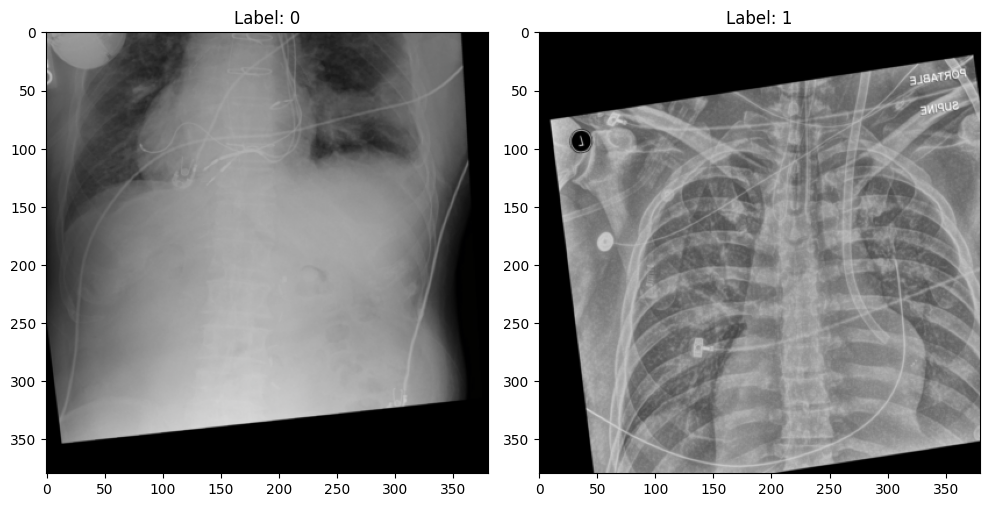

In [21]:
# Plot a few examples
train_dataloader = DataLoader(train_dataset_cls, batch_size=32, shuffle=True)

f, ax = plt.subplots(1, 2, figsize=(10, 5))

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for X, y in train_dataloader:
    # find first label==0
    first_zero = (y == 0).nonzero(as_tuple=True)[0][0].item()
    img = X[first_zero].cpu().numpy()           # C x H x W
    img = np.transpose(img, (1, 2, 0))           # H x W x C

    # undo normalization
    img = img * std + mean
    img = np.clip(img, 0, 1)

    ax[0].imshow(img)
    ax[0].set_title('Label: ' + str(y[first_zero].item()))

    # find first label==1 (if exists), then break
    ones = (y == 1).nonzero(as_tuple=True)[0]
    if ones.numel() > 0:
        first_one = ones[0].item()
        img = X[first_one].cpu().numpy()
        img = np.transpose(img, (1, 2, 0))

        # undo normalization
        img = img * std + mean
        img = np.clip(img, 0, 1)

        ax[1].imshow(img, cmap='gray')
        ax[1].set_title('Label: ' + str(y[first_one].item()))
        break

plt.tight_layout()
plt.show()

In [22]:
class SegmentationDataset(Dataset):
    def __init__(self, dataframe, image_dir, mask_dir, trs=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.df = dataframe

        self.image_ids = self.df['dicom_id'].values
        self.image_paths = self.df['img_path'].values
        self.study_ids = self.df['study_id'].values
        self.subject_ids = self.df['subject_id'].values
        self.labels = self.df['pathology'].values

        self.size = 256
        self.transforms_img = torchvision.transforms.Compose([
                torchvision.transforms.Resize((self.size, self.size)),
                torchvision.transforms.ToTensor(),
                torchvision.transforms.Normalize((0.5,), (0.2,))
            ])

        self.transforms_mask = transforms.Compose([
            torchvision.transforms.Resize((self.size, self.size), interpolation=transforms.InterpolationMode.NEAREST),
            torchvision.transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        image_id = self.image_ids[index]
        study_id = self.study_ids[index]
        subject_id = self.subject_ids[index]
        target = self.labels[index]

        path   = self.image_paths[index]
        image  = Image.open(path).convert('L')
        image = self.transforms_img(image)

        target = torch.tensor(target)

        mask_path = f'{self.mask_dir}/{subject_id}/{study_id}/{image_id}.png'
        mask = Image.open(mask_path)
        mask = self.transforms_mask(mask)

        return image, mask, target

In [23]:
train_dataset_seg = SegmentationDataset(
    train_df,
    f'{DATA_PATH}/files-png',
    f'{DATA_PATH}/segmentation'
)

val_dataset_seg = SegmentationDataset(
    val_df,
    f'{DATA_PATH}/files-png',
    f'{DATA_PATH}/segmentation'
)

test_dataset_seg = SegmentationDataset(
    test_df,
    f'{DATA_PATH}/files-png',
    f'{DATA_PATH}/segmentation'
)

## Task 2 - Classification
* Implement a Convolutional Neural Network for pathology classification. You can choose your preferred one among those explored during the lectures.
* Complete the training and validation loop, and train the model on the training set.
* (Optionally) Optimize hyperparameters or model architecture using this validation set.

In [24]:
# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def train_loop_cls(dataloader, model, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        # Compute prediction and loss
        logits = model(X)
        loss = loss_fn(logits, y)
        # Backpropagation
        loss.backward()
        optimizer.step()

        # accumulate
        running_loss += loss.item() * X.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y).sum().item()
        running_total += y.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc  = running_correct / running_total
    print(f"Train → Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")
    # return model, epoch_loss, epoch_acc
    return model


def val_loop_cls(dataloader, model, loss_fn, device):
    # Set the model to evaluation mode
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits, y)

            running_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == y).sum().item()
            running_total += y.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc  = running_correct / running_total
    print(f" Val  → Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}\n")
    # return epoch_loss, epoch_acc
    return epoch_acc

In [25]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights, efficientnet_b4, EfficientNet_B4_Weights
from torch.utils.data import DataLoader

learning_rate = 1e-4 
batch_size = 32 
epochs = 10 

model_cls = efficientnet_b4(weights=EfficientNet_B4_Weights)
model_cls.classifier[1] = nn.Sequential(
    # nn.Dropout(0.3),
    nn.Linear(1792, 2)
)

train_dataloader = DataLoader(train_dataset_cls, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset_cls, batch_size=batch_size, shuffle=False)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cls.parameters(), lr=learning_rate, weight_decay=1e-4) # torch.optim.SGD(model_enb0.parameters(), lr = learning_rate)#
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=0)

model_cls.to(device)
loss_fn.to(device)

s = time.process_time() # start time

best_acc = 0
best_model = None

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    model_cls = train_loop_cls(train_dataloader, model_cls, loss_fn, optimizer, device)
    lr_scheduler.step()
    test_acc = val_loop_cls(val_dataloader, model_cls, loss_fn, device)

    if test_acc > best_acc:
        best_acc = test_acc
        best_model = model_cls

print("Done!")

torch.save(best_model.state_dict(), './efficientnetb4-pathology-cxr.pth')

e = time.process_time() # end time
print(e - s, "seconds")

Epoch 1
-------------------------------
Train → Loss: 0.6905, Acc: 0.5272
 Val  → Loss: 0.6856, Acc: 0.5467

Epoch 2
-------------------------------
Train → Loss: 0.6856, Acc: 0.5565
 Val  → Loss: 0.6815, Acc: 0.5600

Epoch 3
-------------------------------
Train → Loss: 0.6771, Acc: 0.6025
 Val  → Loss: 0.6770, Acc: 0.5067

Epoch 4
-------------------------------
Train → Loss: 0.6744, Acc: 0.5858
 Val  → Loss: 0.6735, Acc: 0.4933

Epoch 5
-------------------------------
Train → Loss: 0.6697, Acc: 0.6444
 Val  → Loss: 0.6673, Acc: 0.4933

Epoch 6
-------------------------------
Train → Loss: 0.6687, Acc: 0.6192
 Val  → Loss: 0.6629, Acc: 0.5200

Epoch 7
-------------------------------
Train → Loss: 0.6562, Acc: 0.6611
 Val  → Loss: 0.6584, Acc: 0.5600

Epoch 8
-------------------------------
Train → Loss: 0.6555, Acc: 0.6611
 Val  → Loss: 0.6536, Acc: 0.5467

Epoch 9
-------------------------------
Train → Loss: 0.6536, Acc: 0.6736
 Val  → Loss: 0.6502, Acc: 0.6267

Epoch 10
----------

## Task 3 - Segmentation + Classification
* Implement a Convolutional Neural Network for segmentation. Add a classification head on top of it to perform pathology classification.
* Train the model, and observe the training and validation loss across epochs.

*Note: This shows the foundation of transfer learning from segmentation tasks to classification. More sophisticated approaches can be implemented based on using the encoder for classification*

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, num_classes_cls=2, in_channels=3, out_channels=1): # UNet segmentation output is typically 1 channel for binary mask
        super().__init__()
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.maxpool = nn.MaxPool2d(2)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256), # Normalize the vector
            nn.ReLU(),
            nn.Dropout(0.4),      # Prevent overfitting to simple textures
            nn.Linear(256, num_classes_cls)
        )

        # Encoder
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)

        # Bottleneck
        self.bottleneck = self.conv_block(256, 512)

        # Decoder
        self.dec3 = self.conv_block(512 + 256, 256)
        self.dec2 = self.conv_block(256 + 128, 128)
        self.dec1 = self.conv_block(128 + 64, 64)
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c), # Adding batch normalization
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c), # Adding batch normalization
            nn.ReLU(inplace=True),
        )

    def encode(self, x):
        # Encoder
        self.e1 = self.enc1(x)
        self.e2 = self.enc2(F.max_pool2d(self.e1, 2))
        self.e3 = self.enc3(F.max_pool2d(self.e2, 2))
        self.b = self.bottleneck(F.max_pool2d(self.e3, 2))

        return self.b

    def classify(self, b):
        # Classification
        cls_feat = self.avgpool(b).view(b.size(0), -1)
        class_logits = self.classifier(cls_feat)

        return class_logits

    def decode(self, b):
        # Decoder
        self.d3 = self.dec3(torch.cat([F.interpolate(b, scale_factor=2, mode='bilinear', align_corners=True), self.e3], dim=1))
        self.d2 = self.dec2(torch.cat([F.interpolate(self.d3, scale_factor=2, mode='bilinear', align_corners=True), self.e2], dim=1))
        self.d1 = self.dec1(torch.cat([F.interpolate(self.d2, scale_factor=2, mode='bilinear', align_corners=True), self.e1], dim=1))

        out = self.final(self.d1)

        return out

    def forward(self, x):
        b = self.encode(x)

        cls = self.classify(b)
        seg = self.decode(b)

        return cls, seg

In [27]:
def get_segmentation_metrics(pred_mask, true_mask, threshold=0.5):
    # Ensure masks are binary (0 or 1)
    pred_mask = (torch.sigmoid(pred_mask) > threshold).float()
    
    # Flatten tensors to 1D to calculate overlap
    pred_flat = pred_mask.view(-1)
    true_flat = true_mask.view(-1)

    intersection = (pred_flat * true_flat).sum()
    total_pixels = pred_flat.sum() + true_flat.sum()
    union = (pred_flat + true_flat).clamp(0, 1).sum()

    # Dice Similarity Coefficient
    dice = (2. * intersection) / total_pixels if total_pixels > 0 else torch.tensor(1.0)
    
    # Intersection over Union
    iou = intersection / union if union > 0 else torch.tensor(1.0)

    # Pixel-level Precision (TP / (TP + FP))
    # pred_flat.sum() is (TP + FP)
    precision = intersection / pred_flat.sum() if pred_flat.sum() > 0 else torch.tensor(1.0)

    return dice.item(), iou.item(), precision.item()

In [28]:
def train_loop_seg(model, dataloader, optimizer, criterion_seg, criterion_cls, device, epoch):
    model.train()
    total_loss = 0.0

    # Warmup for the first 3 epochs (Epoch 0, 1, 2) to help stabilize training and prevent the classification loss from dominating early on when the segmentation output is still very noisy. 
    # After 3 epochs, we switch to joint training with balanced weights.
    if epoch < 3:
        alpha, beta = 1.0, 0.0  # Only focus on Segmentation
    else:
        alpha, beta = 0.4, 0.6  # Joint training (Balanced weights)

    for images, masks, targets in dataloader:
        optimizer.zero_grad()
        images, masks, targets = images.to(device), masks.to(device), targets.to(device)

        out_cls, out_seg = model(images)

        # Pass raw out_cls (logits) to CrossEntropyLoss (Remove sigmoid)
        loss_seg = criterion_seg(out_seg, masks)
        loss_cls = criterion_cls(out_cls, targets)

        # Weighted combined loss
        loss = (alpha * loss_seg) + (beta * loss_cls)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f'Train Loss: {avg_loss:.7f} (Weights -> Seg: {alpha}, Cls: {beta})')
    return model


def val_loop_seg(model, dataloader, criterion_seg, criterion_cls, device):
    model.eval()
    total_loss_cls = 0.0
    total_loss_seg = 0.0
    correct = 0
    size = len(dataloader.dataset)
    
    all_dice = []
    all_iou = []

    with torch.no_grad():
        for images, masks, targets in dataloader:
            images, masks, targets = images.to(device), masks.to(device), targets.to(device)

            out_cls, out_seg = model(images)

            # Loss calculation using raw logits
            loss_cls = criterion_cls(out_cls, targets)
            loss_seg = criterion_seg(out_seg, masks)

            total_loss_cls += loss_cls.item()
            total_loss_seg += loss_seg.item()

            # Calculate Segmentation Metrics
            dice, iou, precision = get_segmentation_metrics(out_seg, masks)
            all_dice.append(dice)
            all_iou.append(iou)

            # Classification Prediction Logic
            # Use argmax on the raw logits (out_cls)
            preds = out_cls.argmax(dim=1) 
            correct += (preds == targets).sum().item()

    avg_cls = total_loss_cls / len(dataloader)
    avg_seg = total_loss_seg / len(dataloader)
    accuracy = correct / size * 100
    
    mean_dice = np.mean(all_dice)
    mean_iou = np.mean(all_iou)

    print(
        f'Validation — '
        f'Cls Loss: {avg_cls:.7f}  '
        f'Seg Loss: {avg_seg:.7f}  '
        f'Dice: {mean_dice:.4f}  '
        f'IoU: {mean_iou:.4f}  '
        f'Accuracy: {accuracy:.2f}%'
    )
    return avg_cls, avg_seg, accuracy

In [29]:
# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

learning_rate = 1e-4 
batch_size = 16 
epochs = 10 

train_dataset_seg = SegmentationDataset(
    train_df,
    f'{DATA_PATH}/files-png',
    f'{DATA_PATH}/segmentation'
)

val_dataset_seg = SegmentationDataset(
    val_df,
    f'{DATA_PATH}/files-png',
    f'{DATA_PATH}/segmentation'
)

model = UNet(2,1,1)

# Define loss function and optimizer
criterion_seg = nn.BCEWithLogitsLoss()
criterion_cls = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_dataloader = DataLoader(train_dataset_seg, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
val_dataloader = DataLoader(val_dataset_seg, batch_size=1, num_workers=4, pin_memory=True)

model.to(device)
best_loss = 100
best_model = None

val_losses_cls, val_losses_seg,  val_accuracies   = [], [], []
for t in range(epochs):
    print(f"-------------------------------\nEpoch {t+1}")
    model = train_loop_seg(model, train_dataloader, optimizer, criterion_seg, criterion_cls, device, t)
    loss_cls, loss_seg, val_acc = val_loop_seg(model, val_dataloader, criterion_seg, criterion_cls, device)
    if loss_cls < best_loss:
        best_loss=loss_cls
        best_model = model
    val_losses_cls.append(loss_cls)
    val_losses_seg.append(loss_seg)
    val_accuracies.append(val_acc)

print("Done!")
torch.save(best_model.state_dict(), 'unet_seg_cls_pathology_cxr.pth')

-------------------------------
Epoch 1
Train Loss: 0.4910216 (Weights -> Seg: 1.0, Cls: 0.0)
Validation — Cls Loss: 0.6995169  Seg Loss: 0.7901417  Dice: 0.4965  IoU: 0.3325  Accuracy: 49.33%
-------------------------------
Epoch 2
Train Loss: 0.3355642 (Weights -> Seg: 1.0, Cls: 0.0)
Validation — Cls Loss: 0.7124239  Seg Loss: 0.5040323  Dice: 0.7063  IoU: 0.5625  Accuracy: 49.33%
-------------------------------
Epoch 3
Train Loss: 0.3012293 (Weights -> Seg: 1.0, Cls: 0.0)
Validation — Cls Loss: 0.7563338  Seg Loss: 0.2943222  Dice: 0.8805  IoU: 0.7909  Accuracy: 44.00%
-------------------------------
Epoch 4
Train Loss: 0.5475077 (Weights -> Seg: 0.4, Cls: 0.6)
Validation — Cls Loss: 1.0561512  Seg Loss: 0.3252576  Dice: 0.8087  IoU: 0.6856  Accuracy: 49.33%
-------------------------------
Epoch 5
Train Loss: 0.5581952 (Weights -> Seg: 0.4, Cls: 0.6)
Validation — Cls Loss: 0.6381284  Seg Loss: 0.3078833  Dice: 0.8469  IoU: 0.7500  Accuracy: 66.67%
-------------------------------
Epo

## Task 4 - Evaluation
* Implement a few evaluation metrics to compare the performance of the two networks. Remember that the objective is pathology detection, so you must take into account the importance of false positives and false negatives in that context.
* Run inference of the two models on the test set and print a table with the metrics to compare.

Model EN-B4: 
Accuracy: 0.5982532751091703 
F1-score: 0.6805555555555556 
Recall: 0.9607843137254902 
Precision: 0.5268817204301075


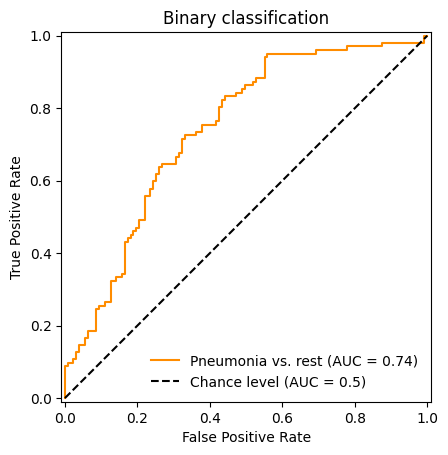

In [ ]:
model_enb4 = efficientnet_b4(weights=EfficientNet_B4_Weights)
model_enb4.classifier[1] = nn.Sequential(nn.Linear(1792, 2))
model_enb4.load_state_dict(torch.load('./efficientnetb4-pathology-cxr.pth'))

test_df = test_df 
test_dataset_cls = ClassificationDataset(test_df, './MIMIC-CXR-png/files-png', train=False, image_size=380, channels=3) 
test_dataloader = DataLoader(test_dataset_cls, batch_size=1, shuffle=False) 

model_enb4.eval()
model_enb4.to(device)

preds_list = []
probs_list = []
label_list = []

with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        out = model_enb4(X)

        probs = nn.functional.softmax(out, dim=1)  # use softmax for multi-logit outputs
        preds = probs.argmax(dim=1)

        probs_list.append(probs[:, 1].item())  # probability for class 1
        preds_list.append(preds.item())
        label_list.append(y.detach().cpu().numpy())

display = RocCurveDisplay.from_predictions(
    label_list, probs_list,
    name=f"Pneumonia vs. rest",
    color="darkorange",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Binary classification",
)
display.ax_.legend(frameon=False)

print(
    f'Model EN-B4:',
    '\nAccuracy:', accuracy_score(label_list, preds_list),
    '\nF1-score:', f1_score(label_list, preds_list),
    '\nRecall:', recall_score(label_list, preds_list),
    '\nPrecision:', precision_score(label_list, preds_list)
)

In [31]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score

def evaluate_model(model, dataloader, device, model_name):
    model.eval()
    model.to(device)

    collected_labels = []
    collected_probs = []
    collected_preds = []

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            
            # Forward pass
            output = model(images)
            
            # Dynamically handle outputs: UNet returns (cls, seg), EfficientNet returns cls
            logits = output[0] if isinstance(output, tuple) else output

            # Calculate probabilities for the positive class (index 1) and hard predictions
            probs = torch.softmax(logits, dim=1)
            preds = (probs[:, 1] > 0.8).long()

            # Accumulate results safely regardless of batch size
            collected_labels.extend(targets.cpu().tolist())
            collected_probs.extend(probs[:, 1].cpu().tolist())
            collected_preds.extend(preds.cpu().tolist())

    # Calculate metrics
    metrics = {
        "Accuracy": accuracy_score(collected_labels, collected_preds),
        "F1-score": f1_score(collected_labels, collected_preds),
        "Recall": recall_score(collected_labels, collected_preds),
        "Precision": precision_score(collected_labels, collected_preds),
        "AUC": roc_auc_score(collected_labels, collected_probs)
    }

    # Print results cleanly
    print(f"\n--- {model_name} Performance ---")
    for key, val in metrics.items():
        print(f"{key:>10}: {val:.4f}")

    return collected_labels, collected_probs

tensor([[ 1.4168, -0.2451]], device='cuda:0')
tensor([[ 1.6058, -1.1574]], device='cuda:0')
tensor([[ 1.3314, -0.8131]], device='cuda:0')
tensor([[ 1.1402, -0.6577]], device='cuda:0')
tensor([[ 2.0025, -1.4279]], device='cuda:0')
tensor([[ 1.9801, -1.4062]], device='cuda:0')
tensor([[ 2.5029, -1.9025]], device='cuda:0')
tensor([[ 1.9103, -1.4173]], device='cuda:0')
tensor([[ 2.4991, -1.8174]], device='cuda:0')
tensor([[ 0.6814, -0.4570]], device='cuda:0')
tensor([[ 1.6967, -1.2662]], device='cuda:0')
tensor([[ 1.8969, -1.3317]], device='cuda:0')
tensor([[ 1.3878, -0.7868]], device='cuda:0')
tensor([[ 1.1405, -0.6191]], device='cuda:0')
tensor([[ 1.7242, -1.0860]], device='cuda:0')
tensor([[ 2.7044, -2.0392]], device='cuda:0')
tensor([[ 3.1911, -2.7741]], device='cuda:0')
tensor([[ 3.2722, -2.2405]], device='cuda:0')
tensor([[ 2.2871, -1.7623]], device='cuda:0')
tensor([[ 0.7913, -0.3356]], device='cuda:0')
tensor([[ 1.3956, -1.0281]], device='cuda:0')
tensor([[ 0.5751, -0.0606]], devic

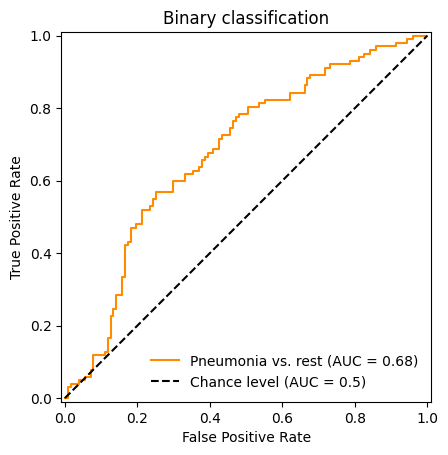

In [32]:
model_unet = UNet(2,1,1)
model_unet.load_state_dict(torch.load('./unet_seg_cls_pathology_cxr.pth'))

test_df = test_df 
test_dataset_cls = ClassificationDataset(test_df, './MIMIC-CXR-png/files-png', train=False, image_size=256, channels=1) 
test_dataloader = DataLoader(test_dataset_cls, batch_size=1, shuffle=False) 

model_unet.eval()
model_unet.to(device)

preds_list = []
probs_list = []
label_list = []

with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        out, _ = model_unet(X)

        print(out[:5]) # See the raw numbers
        
        probs = nn.functional.softmax(out, dim=1)  # use softmax for multi-logit outputs
        preds = probs.argmax(dim=1)

        probs_list.append(probs[:, 1].item())  # probability for class 1
        preds_list.append(preds.item())
        label_list.append(y.detach().cpu().numpy())

display = RocCurveDisplay.from_predictions(
    label_list, probs_list,
    name=f"Pneumonia vs. rest",
    color="darkorange",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Binary classification",
)
display.ax_.legend(frameon=False)

print(
    f'Model U-Net:',
    '\nAccuracy:', accuracy_score(label_list, preds_list),
    '\nF1-score:', f1_score(label_list, preds_list),
    '\nRecall:', recall_score(label_list, preds_list),
    '\nPrecision:', precision_score(label_list, preds_list)
)

In [41]:
from sklearn.metrics import precision_recall_curve

def get_optimal_metrics(y_true, y_prob, model_name):
    # Calculate Precision-Recall curve
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    
    # Calculate F1 score for each threshold
    numerator = 2 * recalls * precisions
    denom = recalls + precisions
    # Avoid division by zero
    f1_scores = np.divide(numerator, denom, out=np.zeros_like(denom), where=denom!=0)
    
    # Find the index of the best F1 score
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    
    # Apply this threshold to create "Hard Predictions" (0 or 1)
    preds_optimized = (np.array(y_prob) >= best_thresh).astype(int)
    
    print(f"\n--- {model_name} (Optimized Threshold: {best_thresh:.4f}) ---")
    print(f"Accuracy:  {accuracy_score(y_true, preds_optimized):.4f}")
    print(f"F1-score:  {f1_score(y_true, preds_optimized):.4f}")
    print(f"Recall:    {recall_score(y_true, preds_optimized):.4f}")
    print(f"Precision: {precision_score(y_true, preds_optimized):.4f}")
    print(f"AUC:       {roc_auc_score(y_true, y_prob):.4f}")
    
    return best_thresh

Visualize the two plots in the same plot


--- EfficientNet-B4 Performance ---
  Accuracy: 0.5546
  F1-score: 0.0000
    Recall: 0.0000
 Precision: 0.0000
       AUC: 0.7410

--- UNet Performance ---
  Accuracy: 0.5590
  F1-score: 0.0381
    Recall: 0.0196
 Precision: 0.6667
       AUC: 0.6791

--------------------
Optimized metrics based on best f1-score threshold:

--- EfficientNet-B4 (Optimized Threshold: 0.5089) ---
Accuracy:  0.6681
F1-score:  0.7185
Recall:    0.9510
Precision: 0.5774
AUC:       0.7410

--- U-Net (Optimized Threshold: 0.1008) ---
Accuracy:  0.6332
F1-score:  0.6613
Recall:    0.8039
Precision: 0.5616
AUC:       0.6791


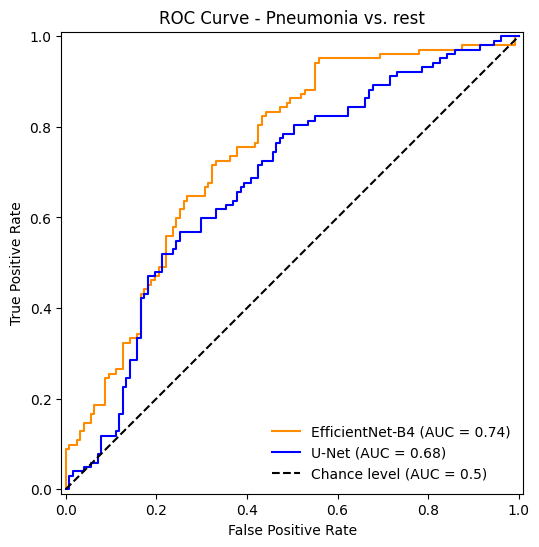

In [48]:
# Load the trained models
model_enb4 = efficientnet_b4(weights=EfficientNet_B4_Weights)
model_enb4.classifier[1] = nn.Sequential(
    nn.Linear(1792, 2)
)
model_enb4.load_state_dict(torch.load('./efficientnetb4-pathology-cxr.pth'))

model_unet = UNet(2,1,1)
model_unet.load_state_dict(torch.load('./unet_seg_cls_pathology_cxr.pth'))

model_enb4.to(device)
model_unet.to(device)

test_dataset_cls_enb4 = ClassificationDataset(
    test_df,
    f'{DATA_PATH}/files-png',
    train=False,
    image_size=380,
    channels=3
)

test_dataset_cls_unet = ClassificationDataset(
    test_df,
    f'{DATA_PATH}/files-png/',
    train=False,
    image_size=256,
    channels=1
)

test_dataloader_enb4 = DataLoader(test_dataset_cls_enb4, batch_size=1, shuffle=False)
test_dataloader_unet = DataLoader(test_dataset_cls_unet, batch_size=1, shuffle=False)

# Evaluate models and get true labels and predicted probabilities
# Note: evaluate_model() prints 'Argmax' results which looks bad (0 Recall) because the default threshold of 0.5 is not optimal for these models (see output for details)
# Instead I use the lists it returns with the helper function get_optimal_metrics() 
label_list_enb4, probs_list_enb4 = evaluate_model(model_enb4, test_dataloader_enb4, device, 'EfficientNet-B4')
label_list_unet, probs_list_unet = evaluate_model(model_unet, test_dataloader_unet, device, 'UNet')

# Calculate optimized metrics based on the best F1-score threshold
print("\n" + "-"*20)
print("Optimized metrics based on best f1-score threshold:")
_ = get_optimal_metrics(label_list_enb4, probs_list_enb4, "EfficientNet-B4")
_ = get_optimal_metrics(label_list_unet, probs_list_unet, "U-Net")

# Plot ROC curves
plt.figure(figsize=(8, 6))

display_enb4 = RocCurveDisplay.from_predictions(
    label_list_enb4, 
    probs_list_enb4,
    name="EfficientNet-B4",
    color="darkorange",
    ax=plt.gca()
)

display_unet = RocCurveDisplay.from_predictions(
    label_list_unet, 
    probs_list_unet,
    name="U-Net",
    color="blue",
    plot_chance_level=True,
    ax=plt.gca()
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Pneumonia vs. rest")
plt.legend(frameon=False)
plt.show()

Loading the models from Project week 3 for comparison


In [44]:
X_train = train_df.drop(['subject_id', 'study_id', 'dicom_id', 'dicom_path', 'labels_encoded', 'pathology','img_path'], axis=1)
y_train = train_df['pathology']

X_test = test_df.drop(['subject_id', 'study_id', 'dicom_id', 'dicom_path', 'labels_encoded', 'pathology','img_path'], axis=1)
y_test = test_df['pathology']

Retrieve previous models

In [45]:
import urllib.request
import zipfile

modelsUrl = "https://uni-bonn.sciebo.de/s/NFrr42TJbWceBZZ/download/previous_models.zip"
modelsZip = "previous_models.zip"
extractDir = "./"

# Download the zip file containing the models
urllib.request.urlretrieve(modelsUrl, modelsZip)

# Extract the contents of the zip file
with zipfile.ZipFile(modelsZip, 'r') as zipRef:
    zipRef.extractall(extractDir)

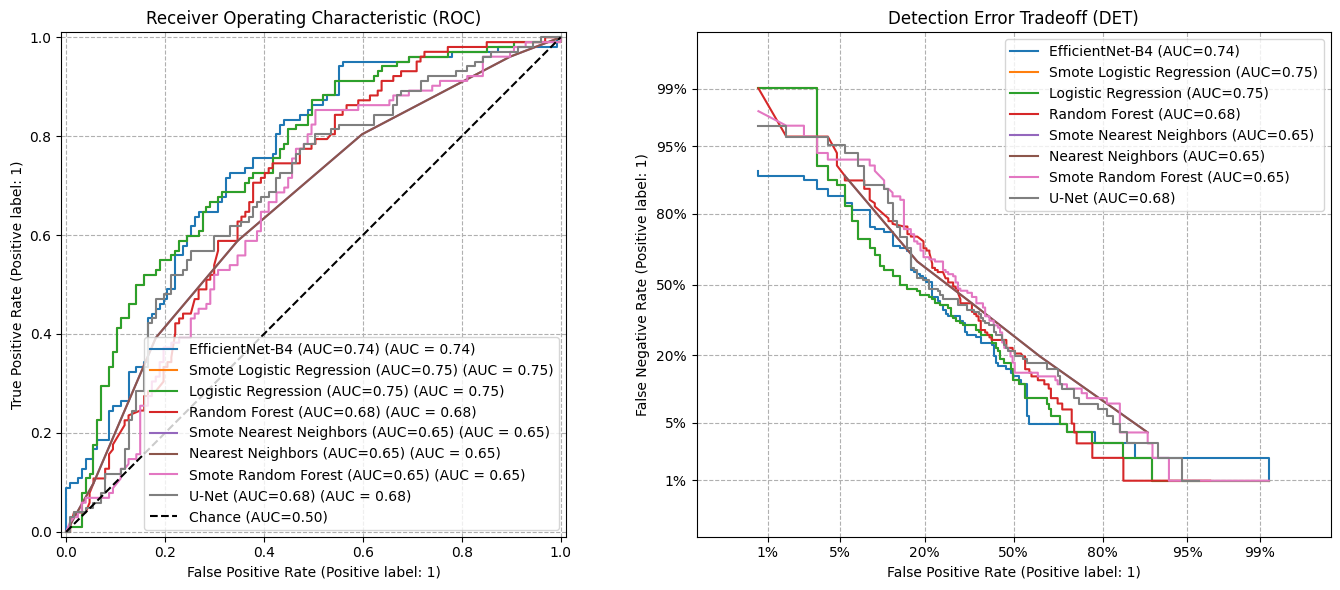

In [47]:
from sklearn.metrics import DetCurveDisplay

def get_model_auc(model_filepath, X_test, y_test):
    mdl = joblib.load(model_filepath)
    # try predict_proba, else decision_function
    if hasattr(mdl, "predict_proba"):
        y_score = mdl.predict_proba(X_test)[:, 1]
    else:
        y_score = mdl.decision_function(X_test)
    return roc_auc_score(y_test, y_score)

# 1) gather AUCs
path = "./"
model_files = [f for f in os.listdir(path)
               if f.startswith("best_model_") and f.endswith(".pkl")]

model_aucs = []
for mf in model_files:
    auc = get_model_auc(path + mf, X_test, y_test)
    model_aucs.append((mf, auc))

# 2) sort descending by AUC
model_aucs.sort(key=lambda x: x[1], reverse=True)

# 3) now plot in that order
fig, (ax_roc, ax_det) = plt.subplots(1, 2, figsize=(14, 6))

# EfficientNet‑B4
auc_enb4 = roc_auc_score(label_list_enb4, probs_list_enb4)
RocCurveDisplay.from_predictions(
    label_list_enb4, 
    probs_list_enb4,
    name=f"EfficientNet-B4 (AUC={auc_enb4:.2f})",
    ax=ax_roc,
    plot_chance_level=False
)
DetCurveDisplay.from_predictions(
    label_list_enb4, 
    probs_list_enb4,
    name=f"EfficientNet-B4 (AUC={auc_enb4:.2f})",
    ax=ax_det
)

for mf, auc in model_aucs:
    mdl = joblib.load(path + mf)
    name = (os.path.basename(mf)
              .replace("best_model_", "")
              .replace(".pkl", "")
              .replace("_", " ")
              .title())
    label = f"{name} (AUC={auc:.2f})"

    # ROC
    RocCurveDisplay.from_estimator(
        mdl, X_test, y_test,
        name=label, ax=ax_roc,
        plot_chance_level=False  # we'll add that line ourselves
    )
    # DET
    DetCurveDisplay.from_estimator(
        mdl, X_test, y_test,
        name=label, ax=ax_det
    )

# U‑Net
auc_unet = roc_auc_score(label_list_unet, probs_list_unet)
RocCurveDisplay.from_predictions(
    label_list_unet, 
    probs_list_unet,
    name=f"U-Net (AUC={auc_unet:.2f})",
    ax=ax_roc,
    plot_chance_level=False
)
DetCurveDisplay.from_predictions(
    label_list_unet, 
    probs_list_unet,
    name=f"U-Net (AUC={auc_unet:.2f})", # Fixed a small typo here from auc_enb4 to auc_unet
    ax=ax_det
)

# add the chance line last
ax_roc.plot([0, 1], [0, 1], "--", color="black", label="Chance (AUC=0.50)")

# titles & grids
ax_roc.set_title("Receiver Operating Characteristic (ROC)")
ax_det.set_title("Detection Error Tradeoff (DET)")
ax_roc.grid(linestyle="--")
ax_det.grid(linestyle="--")

# legends
ax_roc.legend(loc="lower right")
ax_det.legend(loc="upper right")

plt.tight_layout()
plt.show()